# Music by instrument

Classify the dominant instrument(s) in a track using [`Bhaveen/Musical-Instrument-Classification`](https://huggingface.co/Bhaveen/Musical-Instrument-Classification), a `facebook/wav2vec2-base-960h` fine-tuned on 9 instrument classes: acoustic guitar, bass guitar, drum set, electric guitar, flute, hi-hats, keyboard, trumpet, violin.

The model expects mono audio at 16 kHz in 3-second clips (48 000 samples). Our tracks are full songs, so each one gets chopped into 3-second windows; every window is classified and the probabilities averaged into a per-track instrument profile.

One thing to keep in mind: the model was trained on isolated single-instrument clips, and a full band mix is a different beast. Treat the results as a rough sketch of what the model hears, not ground truth.

Tracks compared below (everything in `My Drive/google_colab/music_examples`, same files as the emotion / genre notebooks):
- `Andromida - Real.mp3`
- `Eminem - Lose Yourself.mp3`
- `Linkin Park - In The End.mp3`
- `Nero - Blame You.mp3`
- `Slipknot - Duality.mp3`
- `The Cardigans - My Favorite Game.mp3`

## 1. Install dependencies

In [1]:
!pip install -q transformers torch torchaudio librosa

## 2. Mount Google Drive

After mounting, `My Drive` is available at `/content/drive/MyDrive`.

In [2]:
from google.colab import drive
drive.mount('/content/drive')

AUDIO_DIR = '/content/drive/MyDrive/google_colab/music_examples'
AUDIO_PATHS = [
    f'{AUDIO_DIR}/Andromida - Real.mp3',
    f'{AUDIO_DIR}/Eminem - Lose Yourself.mp3',
    f'{AUDIO_DIR}/Linkin Park - In The End.mp3',
    f'{AUDIO_DIR}/Nero - Blame You.mp3',
    f'{AUDIO_DIR}/Slipknot - Duality.mp3',
    f'{AUDIO_DIR}/The Cardigans - My Favorite Game.mp3',
]

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


## 3. Load the model and processor

In [3]:
import torch
from transformers import AutoFeatureExtractor, AutoModelForAudioClassification

MODEL_ID = 'Bhaveen/Musical-Instrument-Classification'

device = 'cuda' if torch.cuda.is_available() else 'cpu'

extractor = AutoFeatureExtractor.from_pretrained(MODEL_ID)
model = AutoModelForAudioClassification.from_pretrained(MODEL_ID).to(device).eval()

# Instrument labels come straight from the model config.
INSTRUMENT_LABELS = [model.config.id2label[i] for i in range(model.config.num_labels)]

# 16 kHz for wav2vec2
TARGET_SR = extractor.sampling_rate
# The model was trained on fixed 3-second clips (48 000 samples).
CLIP_SECONDS = 3
CLIP_SAMPLES = TARGET_SR * CLIP_SECONDS

print('Target sampling rate:', TARGET_SR)
print('Clip length:', CLIP_SECONDS, 's', f'({CLIP_SAMPLES} samples)')
print('Instrument labels:', INSTRUMENT_LABELS)

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:122: UserWarning: 
Error while fetching `HF_TOKEN` secret value from your vault: 'Requesting secret HF_TOKEN timed out. Secrets can only be fetched when running from the Colab UI.'.
You are not authenticated with the Hugging Face Hub in this notebook.
If the error persists, please let us know by opening an issue on GitHub (https://github.com/huggingface/huggingface_hub/issues/new).
  warnings.warn(


preprocessor_config.json:   0%|          | 0.00/215 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/2.51k [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/378M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/215 [00:00<?, ?it/s]

Target sampling rate: 16000
Clip length: 3 s (48000 samples)
Instrument labels: ['Acoustic_Guitar', 'Bass_Guitar', 'Drum_set', 'Electro_Guitar', 'flute', 'Hi_Hats', 'Keyboard', 'Trumpet', 'Violin']


## 4. Inference helper

`classify()` does the windowing described above and returns two things per
track: the averaged instrument distribution, and each window's top prediction
(kept so we can watch the dominant instrument shift over time).

In [4]:
import os
import numpy as np
import librosa


def classify(path, batch_size=32):
    """Return (mean_probs, window_top_ids, duration_seconds) for one audio file.

    The track is chopped into non-overlapping 3-second windows; the last,
    shorter window is zero-padded to the full clip length.
    """
    waveform, sr = librosa.load(path, sr=TARGET_SR, mono=True)
    duration = len(waveform) / sr

    # Split into 3-second windows, padding the final partial window.
    windows = []
    for start in range(0, len(waveform), CLIP_SAMPLES):
        clip = waveform[start:start + CLIP_SAMPLES]
        if len(clip) < CLIP_SAMPLES:
            clip = np.pad(clip, (0, CLIP_SAMPLES - len(clip)))
        windows.append(clip)

    all_probs = []
    for i in range(0, len(windows), batch_size):
        batch = windows[i:i + batch_size]
        inputs = extractor(batch, sampling_rate=TARGET_SR, return_tensors='pt')
        inputs = {k: v.to(device) for k, v in inputs.items()}
        with torch.no_grad():
            logits = model(**inputs).logits
        all_probs.append(torch.softmax(logits, dim=-1).cpu())

    probs = torch.cat(all_probs, dim=0)        # (n_windows, n_labels)
    mean_probs = probs.mean(dim=0)             # (n_labels,)
    window_top_ids = probs.argmax(dim=-1)      # (n_windows,)
    return mean_probs, window_top_ids, duration


# Classify every track once; the cells below just read `results`.
results = {}
window_preds = {}
for path in AUDIO_PATHS:
    name = os.path.splitext(os.path.basename(path))[0]
    mean_probs, top_ids, duration = classify(path)
    results[name] = mean_probs
    window_preds[name] = top_ids
    print(f'{name}: {duration:.1f}s ({len(top_ids)} windows)')

Andromida - Real: 218.1s (73 windows)
Eminem - Lose Yourself: 326.5s (109 windows)
Linkin Park - In The End: 219.0s (73 windows)
Nero - Blame You: 200.5s (67 windows)
Slipknot - Duality: 218.6s (73 windows)


/tmp/ipykernel_25161/1568462028.py:12: UserWarning: PySoundFile failed. Trying audioread instead.
  waveform, sr = librosa.load(path, sr=TARGET_SR, mono=True)
/usr/local/lib/python3.12/dist-packages/librosa/core/audio.py:184: FutureWarning: librosa.core.audio.__audioread_load
	Deprecated as of librosa version 0.10.0.
	It will be removed in librosa version 1.0.
  y, sr_native = __audioread_load(path, offset, duration, dtype)


The Cardigans - My Favorite Game: 216.3s (73 windows)


## 5. Top prediction per track

The single most likely instrument (averaged over the whole track) plus the
share of 3-second windows where it was the top pick.

In [5]:
for name, probs in results.items():
    top_id = int(probs.argmax())
    top_ids = window_preds[name]
    window_share = (top_ids == top_id).float().mean().item()
    print(f'{name}')
    print(f'  Predicted instrument: {INSTRUMENT_LABELS[top_id]} '
          f'({probs[top_id].item():.2%} mean prob, '
          f'top in {window_share:.0%} of windows)\n')

Andromida - Real
  Predicted instrument: Hi_Hats (18.31% mean prob, top in 41% of windows)

Eminem - Lose Yourself
  Predicted instrument: Trumpet (17.31% mean prob, top in 31% of windows)

Linkin Park - In The End
  Predicted instrument: Acoustic_Guitar (17.83% mean prob, top in 22% of windows)

Nero - Blame You
  Predicted instrument: Hi_Hats (18.40% mean prob, top in 54% of windows)

Slipknot - Duality
  Predicted instrument: Hi_Hats (20.90% mean prob, top in 52% of windows)

The Cardigans - My Favorite Game
  Predicted instrument: Violin (17.84% mean prob, top in 36% of windows)



## 6. Side-by-side comparison

Full per-instrument mean probabilities for all six tracks, sorted by the first track's scores.

In [6]:
import pandas as pd

comparison = pd.DataFrame(
    {name: [probs[i].item() for i in range(len(INSTRUMENT_LABELS))]
     for name, probs in results.items()},
    index=INSTRUMENT_LABELS,
)
comparison.index.name = 'instrument'

# Sort by the first track so the table is easier to scan.
comparison = comparison.sort_values(by=comparison.columns[0], ascending=False)

(comparison * 100).round(2).style.format('{:.2f}%')

,Andromida - Real,Eminem - Lose Yourself,Linkin Park - In The End,Nero - Blame You,Slipknot - Duality,The Cardigans - My Favorite Game
instrument,,,,,,
Hi_Hats,18.31%,13.55%,14.70%,18.40%,20.90%,13.30%
Trumpet,17.70%,17.31%,16.53%,16.73%,20.41%,16.33%
Acoustic_Guitar,16.67%,13.70%,17.83%,15.25%,14.31%,16.85%
Electro_Guitar,14.49%,11.78%,15.26%,13.04%,12.11%,14.24%
Violin,11.30%,11.64%,14.22%,13.66%,10.73%,17.84%
Keyboard,6.25%,12.62%,6.14%,6.44%,6.42%,5.93%
Drum_set,5.40%,6.81%,5.04%,5.60%,5.16%,4.59%
flute,4.96%,6.54%,5.45%,5.89%,5.12%,5.94%
Bass_Guitar,4.91%,6.04%,4.84%,4.99%,4.83%,4.98%


## 7. Instrument timeline

How the per-window top instrument changes over the course of each track.
Expect it to jump around; the model only hears 3 seconds at a time.

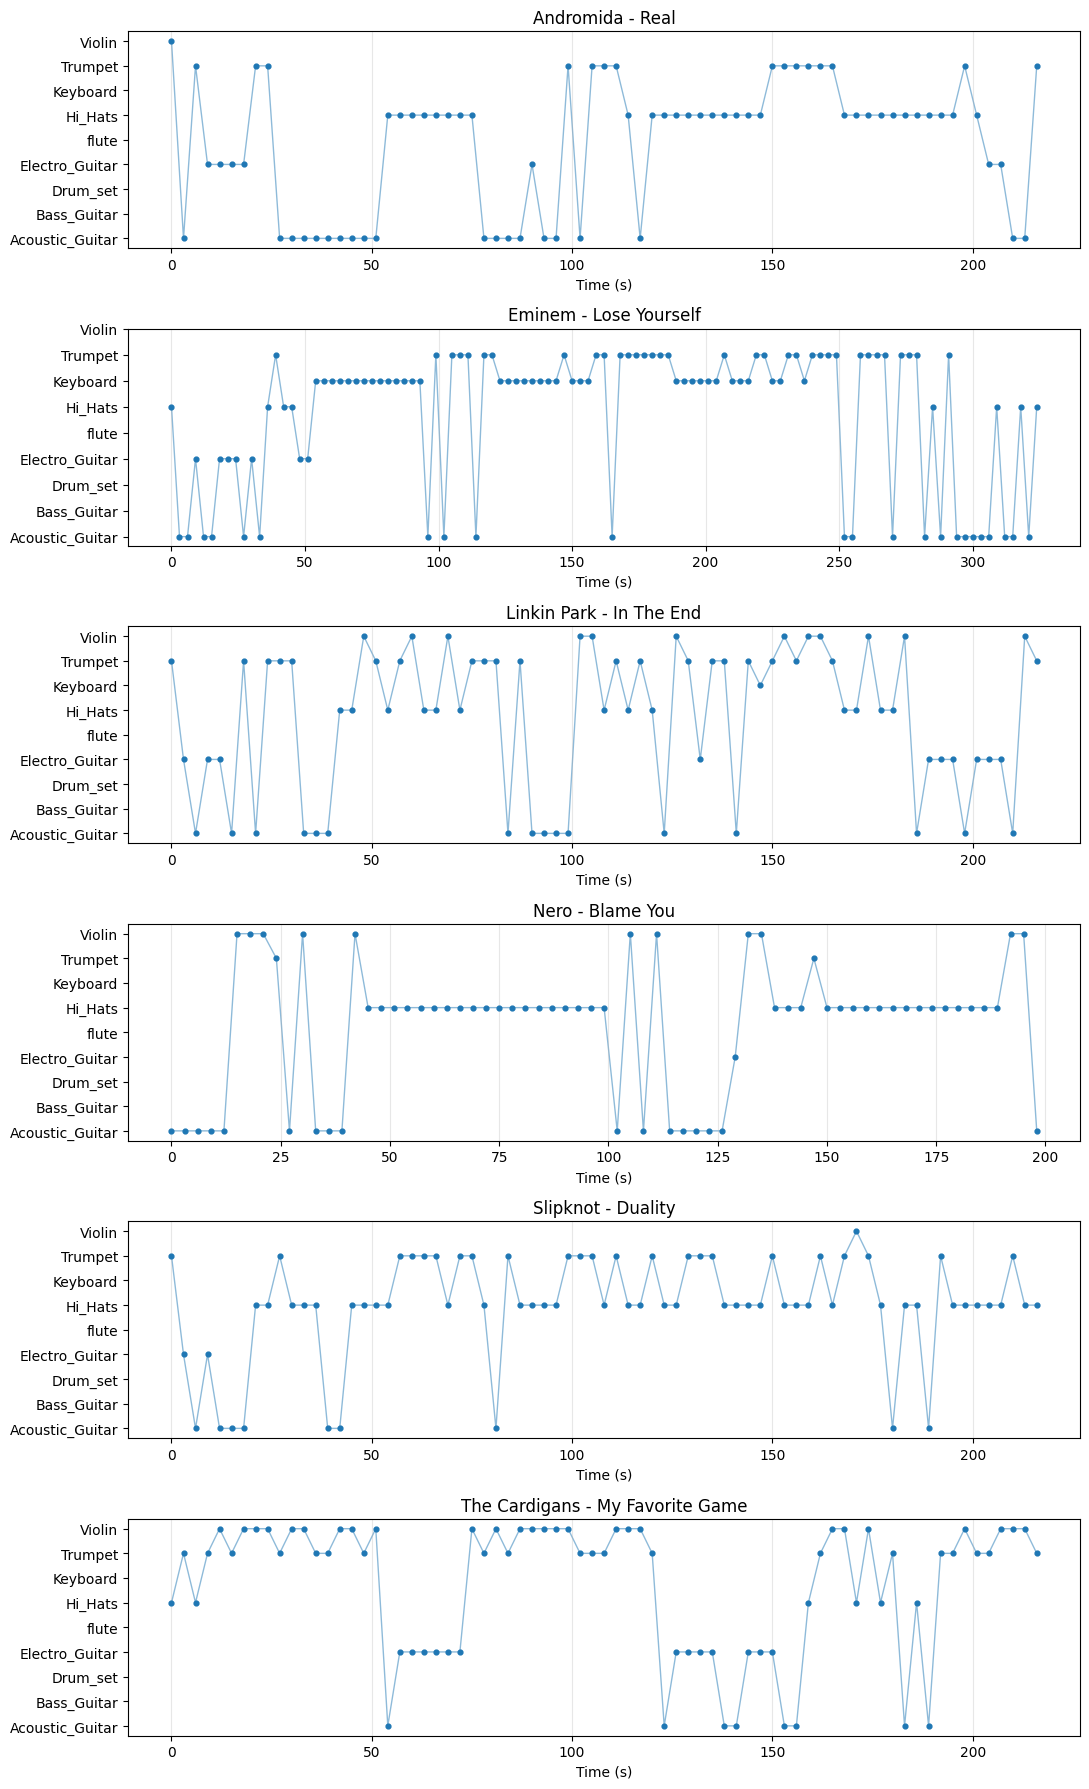

In [7]:
import matplotlib.pyplot as plt

fig, axes = plt.subplots(len(window_preds), 1, figsize=(11, 3 * len(window_preds)),
                         squeeze=False)
for ax, (name, top_ids) in zip(axes[:, 0], window_preds.items()):
    times = np.arange(len(top_ids)) * CLIP_SECONDS
    ax.plot(times, top_ids.numpy(), linewidth=1, alpha=0.5, zorder=1)
    ax.scatter(times, top_ids.numpy(), s=12, zorder=2)
    ax.set_yticks(range(len(INSTRUMENT_LABELS)))
    ax.set_yticklabels(INSTRUMENT_LABELS)
    ax.set_xlabel('Time (s)')
    ax.set_title(name)
    ax.grid(True, axis='x', alpha=0.3)

plt.tight_layout()
plt.show()